In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/bluestock_mf.db')

In [2]:
import pandas as pd

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

tables

,name
0,02_nav_history_clean
1,07_scheme_performance_clean
2,08_investor_transactions_clean


In [4]:
nav = pd.read_sql("""
SELECT * FROM '02_nav_history_clean'
""", conn)

performance = pd.read_sql("""
SELECT * FROM '07_scheme_performance_clean'
""", conn)

transactions = pd.read_sql("""
SELECT * FROM '08_investor_transactions_clean'
""", conn)

In [5]:
print(nav.shape)
print(performance.shape)
print(transactions.shape)

(46000, 3)
(40, 19)
(32778, 13)


In [6]:
print(nav.columns)
print(performance.columns)
print(transactions.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [7]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [9]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [10]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [11]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

In [12]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [13]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [14]:
var_results = []

for code, grp in nav.groupby('amfi_code'):

    returns = grp['daily_return'].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append({
        'amfi_code': code,
        'VaR_95': var95,
        'CVaR_95': cvar95
    })

var_df = pd.DataFrame(
    var_results
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
var_df.to_csv(
    '../outputs/var_cvar_report.csv',
    index=False
)

print("Saved Successfully")

Saved Successfully


In [16]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [17]:
top5 = (
    performance
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(5)
)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [18]:
def rolling_sharpe(returns, window=90):

    return (
        returns.rolling(window).mean()
        /
        returns.rolling(window).std()
    ) * np.sqrt(252)

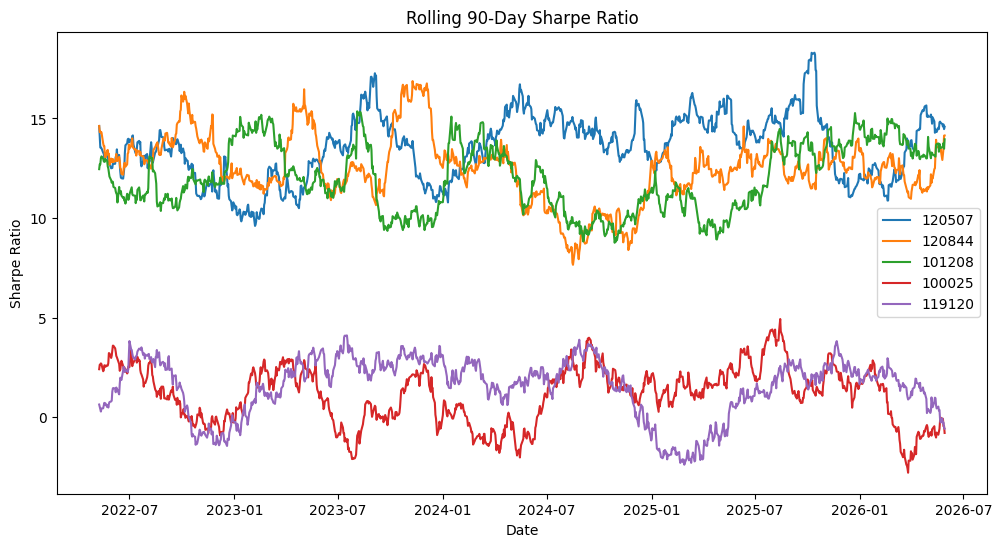

In [19]:
plt.figure(figsize=(12,6))

for code in top5['amfi_code']:

    temp = nav[
        nav['amfi_code'] == code
    ]

    rs = rolling_sharpe(
        temp['daily_return']
    )

    plt.plot(
        temp['date'],
        rs,
        label=str(code)
    )

plt.title(
    'Rolling 90-Day Sharpe Ratio'
)

plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')

plt.legend()

plt.show()

Chart Saved Successfully


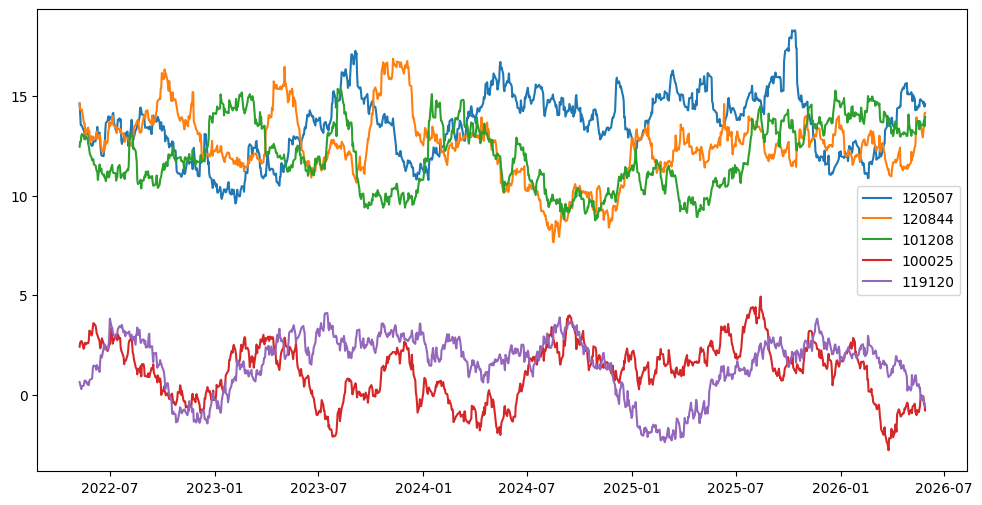

In [20]:
plt.figure(figsize=(12,6))

for code in top5['amfi_code']:

    temp = nav[
        nav['amfi_code'] == code
    ]

    rs = rolling_sharpe(
        temp['daily_return']
    )

    plt.plot(
        temp['date'],
        rs,
        label=str(code)
    )

plt.legend()

plt.savefig(
    '../outputs/rolling_sharpe_chart.png'
)

print("Chart Saved Successfully")

In [21]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

In [22]:
first_txn = (
    transactions
    .groupby('investor_id')
    ['transaction_date']
    .min()
)

In [23]:
transactions = transactions.merge(
    first_txn.rename('first_date'),
    on='investor_id'
)

transactions['cohort_year'] = (
    transactions['first_date']
    .dt.year
)

In [24]:
cohort = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum'),
        investors=('investor_id','nunique')
    )
    .reset_index()
)

cohort

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [25]:
cohort.to_csv(
    '../outputs/cohort_analysis.csv',
    index=False
)

print("Cohort report saved")

Cohort report saved


In [26]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

In [27]:
sip = sip.sort_values(
    ['investor_id','transaction_date']
)

In [28]:
sip['gap_days'] = (
    sip.groupby('investor_id')
       ['transaction_date']
       .diff()
       .dt.days
)

In [29]:
sip_gap['status'] = np.where(
    sip_gap['gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_gap.head()

NameError: name 'sip_gap' is not defined

In [30]:
sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_date,cohort_year,gap_days


In [31]:
sip.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'first_date',
       'cohort_year', 'gap_days'],
      dtype='object')

In [32]:
sip_gap = (
    sip.groupby('investor_id')
       ['gap_days']
       .mean()
       .reset_index()
)

sip_gap.head()

,investor_id,gap_days


In [33]:
sip_gap['status'] = np.where(
    sip_gap['gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_gap.head()

,investor_id,gap_days,status


In [34]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

The fund with the highest VaR (95%) exhibited the largest downside risk.


In [35]:
risk = "Moderate"   # Change to Low / Moderate / High

recommendations = (
    performance[
        performance['risk_grade'] == risk
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

recommendations[
    [
        'scheme_name',
        'risk_grade',
        'sharpe_ratio',
        'return_3yr_pct'
    ]
]

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41


 CVaR analysis identified the fund with the highest tail-risk exposure.

In [36]:
recommendations.to_csv(
    '../outputs/recommendations.csv',
    index=False
)

print("Recommendations saved")

Recommendations saved


 The top investor cohort contributed the largest total investment amount.

In [37]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

,name
0,02_nav_history_clean
1,07_scheme_performance_clean
2,08_investor_transactions_clean


SIP continuity analysis identified active and at-risk investors based on average investment gaps.
The fund with the highest Sharpe Ratio delivered the best risk-adjusted performance.